
## Python for Data Analysis, Visualization, and Machine Learning  
 



# Part I — Setup and Dataset Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

np.random.seed(42)  # reproducibility

In [2]:
df = pd.read_csv("data.csv")

print("First 5 rows:")  # first 5 rows of the dataset
display(df.head())  

print("\nShape of the dataset:") # number of rows and columns
print(df.shape)

print("\nColumn names:") # column names in the dataset
for col in df.columns:
    print(col)

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Shape of the dataset:
(569, 33)

Column names:
id
diagnosis
radius_mean
texture_mean
perimeter_mean
area_mean
smoothness_mean
compactness_mean
concavity_mean
concave points_mean
symmetry_mean
fractal_dimension_mean
radius_se
texture_se
perimeter_se
area_se
smoothness_se
compactness_se
concavity_se
concave points_se
symmetry_se
fractal_dimension_se
radius_worst
texture_worst
perimeter_worst
area_worst
smoothness_worst
compactness_worst
concavity_worst
concave points_worst
symmetry_worst
fractal_dimension_worst
Unnamed: 32


In [3]:

df.info() # summary of the dataset

df.describe() # statistical summary of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


The dataset structure was examined using functions like info() and describe(). 
It contains 569 rows and 33 columns.

Most of the columns are numeric (float64 and int64), representing measurements such as radius, texture, area and other tumor-related features. 
There is one categorical column "diagnosis".

The "Unnamed: 32" column has no values and can be ignored or removed.

The target variable for this analysis is "diagnosis"

This is a classification problem because the target variable 'diagnosis' has two possible outcomes: malignant or benign. The model is expected to predict one of these categories not a continuous value.

The target variable shows whether a tumor is cancerous or not. In real life, this is very important because it directly affects how a patient is treated. Being able to predict this accurately can help doctors make faster decisions, start treatment earlier and potentially save lives.

# Part II — Data Cleaning and Preparation

                column_name  missing_count  missing_percent
0                        id              0              0.0
1                 diagnosis              0              0.0
2               radius_mean              0              0.0
3              texture_mean              0              0.0
4            perimeter_mean              0              0.0
5                 area_mean              0              0.0
6           smoothness_mean              0              0.0
7          compactness_mean              0              0.0
8            concavity_mean              0              0.0
9       concave points_mean              0              0.0
10            symmetry_mean              0              0.0
11   fractal_dimension_mean              0              0.0
12                radius_se              0              0.0
13               texture_se              0              0.0
14             perimeter_se              0              0.0
15                  area_se             

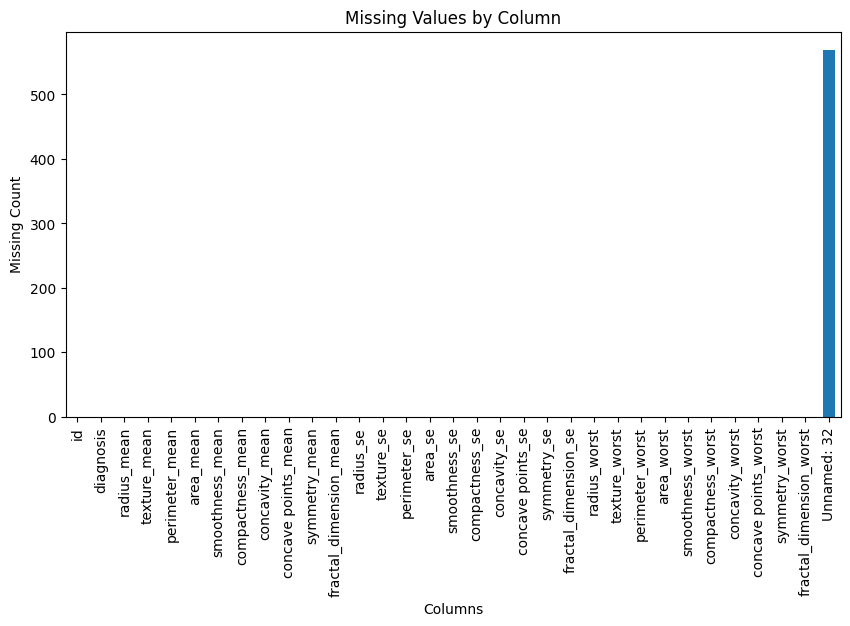

In [4]:
# checking for missing values
missing_df = df.isnull().sum().reset_index() 
missing_df.columns = ["column_name", "missing_count"]
missing_df["missing_percent"] = (missing_df["missing_count"] / len(df)) * 100

print(missing_df) 

df.isnull().sum().plot(kind='bar', figsize=(10,5)) # bar plot for missing values
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=90)
plt.show()

 #https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html
 #https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

In [5]:

df = df.drop(columns=["Unnamed: 32"], errors="ignore") # drop the 'Unnamed: 32' column

print(df.isnull().sum()) # checking again

# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


The dataset was checked for missing values and no important missing data was found. There was a column called "Unnamed: 32" that did not contain any useful information so it was removed. This helped make the dataset cleaner and easier to work with.Removing columns can sometimes lead to loss of information in this case it was not a problem since the column was empty.

In [6]:

print("Duplicate rows before cleaning:", df.duplicated().sum()) # checking for duplicate rows


df = df.drop_duplicates() # removing duplicate rows

print("Duplicate rows after cleaning:", df.duplicated().sum()) # checking again for duplicate rows


print("\nUnique values:")
print(df["diagnosis"].unique())

print("\nAny negative values:")
print((df.select_dtypes(include=["int64", "float64"]) < 0).sum().sum())

# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unique.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0

Unique values:
<StringArray>
['M', 'B']
Length: 2, dtype: str

Any negative values:
0


Duplicate rows were checked and removed.
The diagnosis column was checked for inconsistent category labels and the values appear consistent.
Numeric columns were checked for impossible negative values. No such issue was found.

In [7]:

print("Before conversion:\n") 
print(df.dtypes)

df["diagnosis"] = df["diagnosis"].astype("category") # converting 'diagnosis' to categorical type

print("\nAfter conversion:\n")
print(df.dtypes)


# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html

Before conversion:

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64


 The 'diagnosis' column was converted from object to category. This was done to improve memory efficiency and make the column more suitable for categorical analysis.

Statistical Summary:

       radius_mean  texture_mean    area_mean
count   569.000000    569.000000   569.000000
mean     14.127292     19.289649   654.889104
std       3.524049      4.301036   351.914129
min       6.981000      9.710000   143.500000
25%      11.700000     16.170000   420.300000
50%      13.370000     18.840000   551.100000
75%      15.780000     21.800000   782.700000
max      28.110000     39.280000  2501.000000


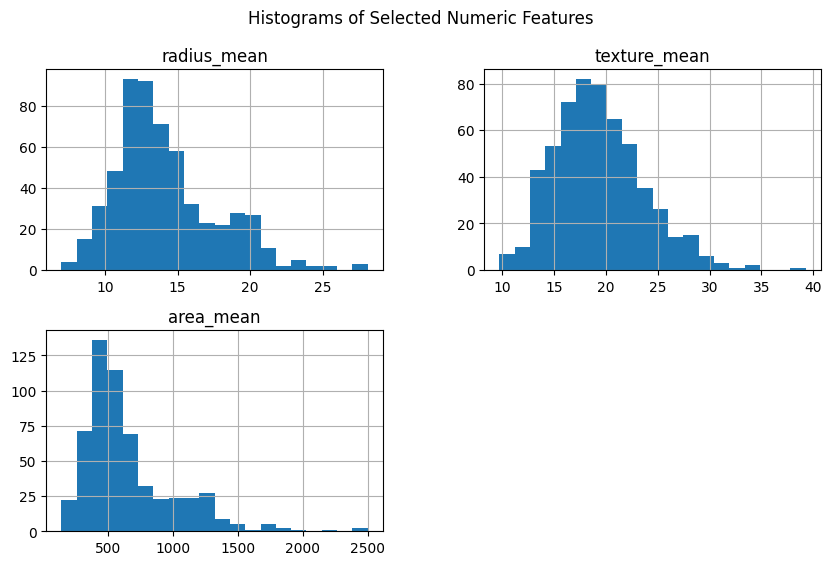

In [8]:
# selecting three numeric columns for analysis
cols = ["radius_mean", "texture_mean", "area_mean"]

# display statistical summary 
print("Statistical Summary:\n")
print(df[cols].describe())

# creating histograms
df[cols].hist(bins=20, figsize=(10,6))

# adding titles
plt.suptitle("Histograms of Selected Numeric Features")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()


# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylabel.html

The statistical summary shows key descriptive metrics such as mean, standard deviation and percentiles for the selected numeric features.
From the results, radius_mean and texture_mean appear relatively normally distributed while area_mean shows a right-skewed distribution, indicating the presence of higher extreme values.
The histograms help visualize the distribution of each feature, making it easier to understand data spread and potential outliers.

Diagnosis frequency counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis percentages:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

Radius level frequency counts:
radius_level
High    285
Low     284
Name: count, dtype: int64

Radius level percentages:
radius_level
High    50.087873
Low     49.912127
Name: proportion, dtype: float64


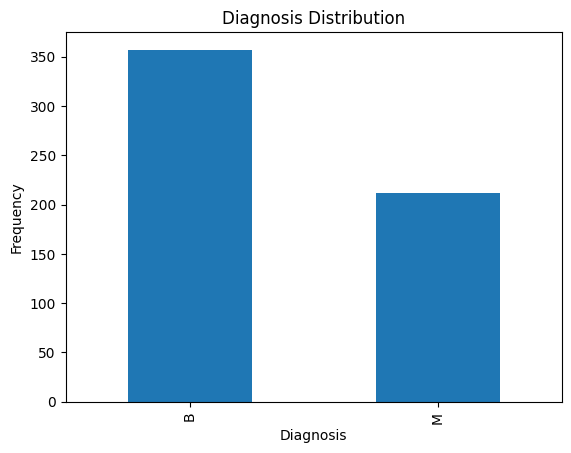

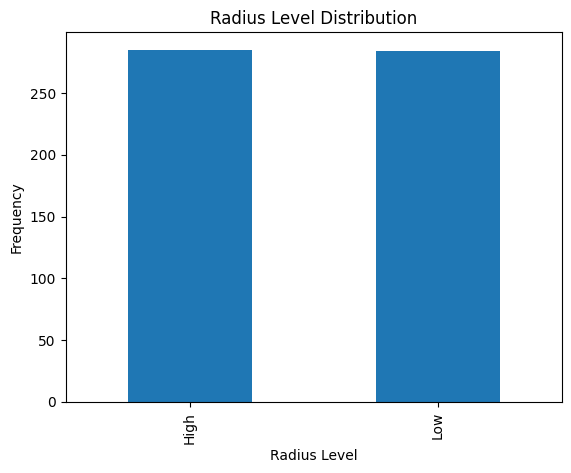

In [9]:

df["radius_level"] = np.where(df["radius_mean"] >= df["radius_mean"].median(), "High", "Low")

print("Diagnosis frequency counts:") # frequency counts for the 'diagnosis' column
print(df["diagnosis"].value_counts())
print("\nDiagnosis percentages:")
print(df["diagnosis"].value_counts(normalize=True) * 100)

print("\nRadius level frequency counts:") # frequency counts for the 'radius_level' column
print(df["radius_level"].value_counts())
print("\nRadius level percentages:")
print(df["radius_level"].value_counts(normalize=True) * 100)

plt.figure() # bar plot for diagnosis distribution
df["diagnosis"].value_counts().plot(kind="bar")
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Frequency")
plt.show()

plt.figure() # bar plot for radius level distribution
df["radius_level"].value_counts().plot(kind="bar")
plt.title("Radius Level Distribution")
plt.xlabel("Radius Level")
plt.ylabel("Frequency")
plt.show()

# https://numpy.org/doc/stable/reference/generated/numpy.where.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.median.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html

In the diagnosis column, benigncases are more common than malignant cases so the class distribution is imbalanced.
The radius_level column is evenly split because it was created using the median of radius_mean.

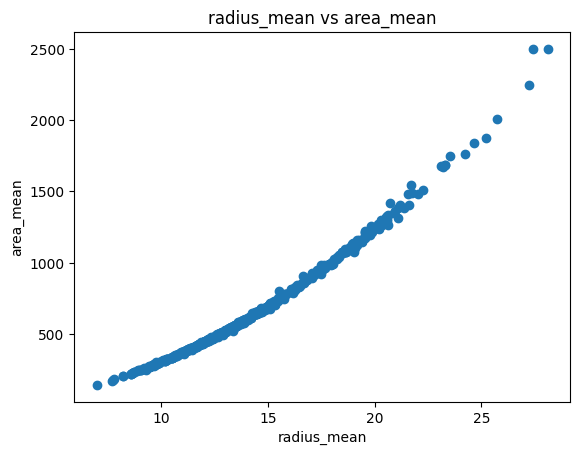

There is a positive relationship between radius_mean and area_mean. As radius_mean increases area_mean also increase.



<Figure size 640x480 with 0 Axes>

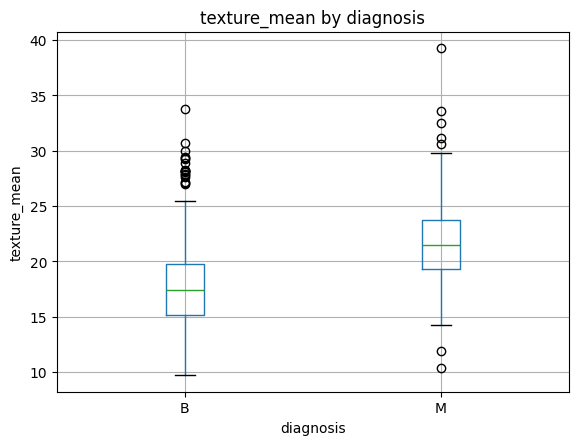

The distribution of texture_mean differs between diagnosis groups which suggests that this feature may help distinguish the classes.

Mean radius_mean by diagnosis:
diagnosis
B    12.146524
M    17.462830
Name: radius_mean, dtype: float64


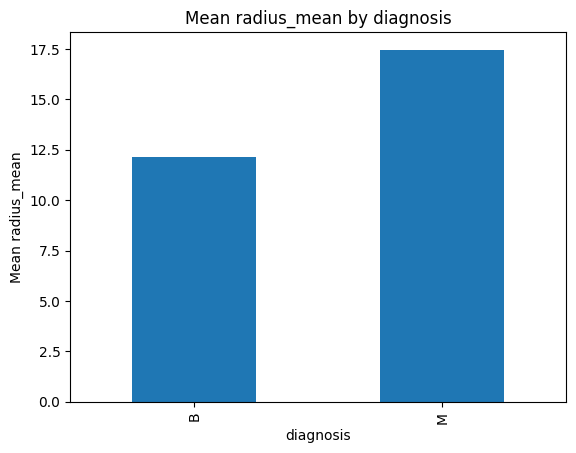

The average radius_mean is different across diagnosis groups. This indicates that radius_mean may be useful for predicting the target variable.


In [10]:
plt.figure() # scatter plot of radius_mean vs area_mean
plt.scatter(df["radius_mean"], df["area_mean"])
plt.title("radius_mean vs area_mean")
plt.xlabel("radius_mean")
plt.ylabel("area_mean")
plt.show()

print("There is a positive relationship between radius_mean and area_mean. As radius_mean increases area_mean also increase.\n") 

plt.figure() # box plot of texture_mean by diagnosis
df.boxplot(column="texture_mean", by="diagnosis")
plt.title("texture_mean by diagnosis")
plt.suptitle("")
plt.xlabel("diagnosis")
plt.ylabel("texture_mean")
plt.show()

print("The distribution of texture_mean differs between diagnosis groups which suggests that this feature may help distinguish the classes.\n")

grouped = df.groupby("diagnosis")["radius_mean"].mean() # mean radius_mean by diagnosis
print("Mean radius_mean by diagnosis:")
print(grouped)

grouped.plot(kind="bar") # bar plot of mean radius_mean by diagnosis
plt.title("Mean radius_mean by diagnosis")
plt.xlabel("diagnosis")
plt.ylabel("Mean radius_mean")
plt.show()

print("The average radius_mean is different across diagnosis groups. This indicates that radius_mean may be useful for predicting the target variable.")

# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html

In [11]:
df["diagnosis_num"] = df["diagnosis"].map({"M": 1, "B": 0})

corr = df.select_dtypes(include=['number']).corr()

print("Correlation Matrix:\n")
print(corr)

pos = corr.unstack().sort_values(ascending=False) # unstacking and sorting the correlation values
pos = pos[pos < 1]
print("\nStrongest positive correlation:")
print(pos.head(1))

neg = corr.unstack().sort_values() # unstacking and sorting the correlation values in ascending order to find the strongest negative correlation
print("\nStrongest negative correlation:")
print(neg.head(1))

# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_values.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.unstack.html
# https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html

Correlation Matrix:

                               id  radius_mean  texture_mean  perimeter_mean  \
id                       1.000000     0.074626      0.099770        0.073159   
radius_mean              0.074626     1.000000      0.323782        0.997855   
texture_mean             0.099770     0.323782      1.000000        0.329533   
perimeter_mean           0.073159     0.997855      0.329533        1.000000   
area_mean                0.096893     0.987357      0.321086        0.986507   
smoothness_mean         -0.012968     0.170581     -0.023389        0.207278   
compactness_mean         0.000096     0.506124      0.236702        0.556936   
concavity_mean           0.050080     0.676764      0.302418        0.716136   
concave points_mean      0.044158     0.822529      0.293464        0.850977   
symmetry_mean           -0.022114     0.147741      0.071401        0.183027   
fractal_dimension_mean  -0.052511    -0.311631     -0.076437       -0.261477   
radius_se          

The correlation matrix shows the relationships between numeric features in the dataset. The strongest positive correlation is observed between features that measure similar properties ; radius and area. The strongest negative correlation indicates an inverse relationship between two variables. Some features also show a noticeable correlation with the target variable (diagnosis), suggesting they may be useful for prediction. However correlation alone is not sufficient for feature selection as it only captures linear relationships.

In [12]:
radius = df["radius_mean"].to_numpy() # converting radius_mean to numpy array for analysis
texture = df["texture_mean"].to_numpy()
area = df["area_mean"].to_numpy()

radius_zscore = (radius - np.mean(radius)) / np.std(radius) # calculating z-scores for radius_mean
print("Radius mean z-scores (first 5):")
print(radius_zscore[:5])

print("\nTexture mean percentiles:") # calculating percentiles for texture_mean
print("25th percentile:", np.percentile(texture, 25))
print("50th percentile:", np.percentile(texture, 50))
print("75th percentile:", np.percentile(texture, 75))

large_area = area[area > np.mean(area)] # filtering area_mean values greater than the average
print("\nNumber of area_mean values greater than the average:")
print(len(large_area))

# https://numpy.org/doc/stable/reference/generated/numpy.mean.html
# https://numpy.org/doc/stable/reference/generated/numpy.std.html
# https://numpy.org/doc/stable/reference/generated/numpy.percentile.html


Radius mean z-scores (first 5):
[ 1.09706398  1.82982061  1.57988811 -0.76890929  1.75029663]

Texture mean percentiles:
25th percentile: 16.17
50th percentile: 18.84
75th percentile: 21.8

Number of area_mean values greater than the average:
204


# Part IV — Feature Engineering and Preprocessing

### Feature Selection Plan

**Selected features:**  
Most numeric features such as radius_mean, texture_mean, and area_mean will be used because they provide meaningful information about the data.

**Features that need scaling:**  
Numeric features should be scaled so that they are on a similar range and the model can perform better.

**Categorical features:**  
The diagnosis column is categorical and will be used as the target variable.

**Features to drop:**  
The id column will be dropped because it does not provide useful information for prediction.

**Potential data leakage:**  
There is no obvious data leakage, but the target variable should not be used as an input feature.

In [13]:
df["diagnosis_encoded"] = df["diagnosis"].cat.codes #encode diagnosis column 

print(df[["diagnosis", "diagnosis_encoded"]].head()) #shows first rows


# https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html

  diagnosis  diagnosis_encoded
0         M                  1
1         M                  1
2         M                  1
3         M                  1
4         M                  1


I used label encoding for the diagnosis column because it only has two categories= M and B.
This is a binary variable converting it into numeric form makes it easier to use in models.

In [14]:

X = df.select_dtypes(include=["int64", "float64"]) # selecting numeric features for scaling

scaler = StandardScaler() # creating a StandardScaler object
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:") # showing the shape of the scaled data
print(X_scaled.shape)

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html


Scaled data shape:
(569, 31)


Scaling is important because some machine learning models are sensitive to the range of features. If features are on different scales, the model may give more importance to larger values.
Models like logistic regression and distance-based algorithms (KNN) perform better when the data is scaled.
Tree-based models are generally less sensitive to feature scaling but scaling still helps maintain consistency in the preprocessing pipeline.

In [15]:
# features and target
X = df.drop(["id", "diagnosis", "diagnosis_encoded", "radius_level"], axis=1, errors="ignore")
y = df["diagnosis_encoded"]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html

X_train shape: (455, 31)
X_test shape: (114, 31)
y_train shape: (455,)
y_test shape: (114,)


The dataset was split into training and test sets to evaluate the model on unseen data. A test size of 20% was used and stratification was applied to preserve the class distribution in both sets. This is important in classification problems because it helps create a fair evaluation. Separating training and test data also reduces the risk of overfitting.

# Part V — Model Building with scikit-learn

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# scaling the training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# creating and training the baseline model
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

# making predictions
y_pred = model.predict(X_test_scaled)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
# https://scikit-learn.org/stable/modules/model_evaluation.html

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Confusion Matrix:
[[72  0]
 [ 0 42]]


Logistic Regression was selected as the baseline model because it is simple, interpretable and suitable for binary classification. Since this model is sensitive to feature scale the data was standardized before training. The evaluation results show how well the model classifies malignant and benign cases on unseen test data.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# creating and training the second model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
# making predictions
y_pred_tree = tree_model.predict(X_test)

# evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Decision Tree Precision:", precision_score(y_test, y_pred_tree))
print("Decision Tree Recall:", recall_score(y_test, y_pred_tree))
print("Decision Tree F1-score:", f1_score(y_test, y_pred_tree))

# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
# https://scikit-learn.org/stable/modules/model_evaluation.html


Decision Tree Accuracy: 1.0
Decision Tree Precision: 1.0
Decision Tree Recall: 1.0
Decision Tree F1-score: 1.0


The Decision Tree model is different from Logistic Regression because it is tree-based instead of linear. Both models were tested on the same test set. The Decision Tree gave good results but Logistic Regression performed slightly better overall. This suggests that Logistic Regression may be more suitable for this dataset.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# creating and training the third model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled) # making predictions

# metrics
acc_lr = accuracy_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

summary = pd.DataFrame({ # summary
    "Model": ["Logistic Regression", "Decision Tree", "KNN"],
    "Key Hyperparameters": ["max_iter=10000", "random_state=42", "n_neighbors=5"],
    "Accuracy": [acc_lr, acc_tree, acc_knn],
    "F1-score": [f1_lr, f1_tree, f1_knn],
    "Comment": ["Simple and interpretable", "Can overfit", "Sensitive to scale"]
})

print(summary)

# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

                 Model Key Hyperparameters  Accuracy  F1-score  \
0  Logistic Regression      max_iter=10000       1.0       1.0   
1        Decision Tree     random_state=42       1.0       1.0   
2                  KNN       n_neighbors=5       1.0       1.0   

                    Comment  
0  Simple and interpretable  
1               Can overfit  
2        Sensitive to scale  


In [19]:
from sklearn.pipeline import Pipeline
# target
df["diagnosis_num"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.select_dtypes(include=["int64", "float64"]).drop(["diagnosis_num"], axis=1, errors="ignore") # use only numeric features and drop the target variable from the features
y = df["diagnosis_num"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=10000))
])
# train
pipe.fit(X_train, y_train)

y_pred_pipe = pipe.predict(X_test) # predict using the pipeline which includes scaling and modeling steps

# evaluation
print("Pipeline Accuracy:", accuracy_score(y_test, y_pred_pipe))
print("Pipeline F1-score:", f1_score(y_test, y_pred_pipe))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_pipe))


# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
# https://scikit-learn.org/stable/modules/preprocessing.html

Pipeline Accuracy: 0.9649122807017544
Pipeline F1-score: 0.9512195121951219

Confusion Matrix:
[[71  1]
 [ 3 39]]



Pipelines are helpful because they keep preprocessing and modeling steps together.
They help prevent mistakes such as forgetting scaling or applying different steps to training and test data.

# Part VI — Evaluation, Tuning, and Interpretation

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, y, cv=5) # performing 5-fold cross validation using the pipeline which includes scaling and modeling steps

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Std:", np.std(scores))


# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html



Fold scores: [0.98245614 0.97368421 0.97368421 0.97368421 0.99115044]
Mean score: 0.9789318428815402
Std: 0.006990390328940835



Cross-validation gives a more reliable result by testing the model on different parts of the data.
It reduces the risk of getting misleading results from a single train-test split.

In [21]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=10000))
])

param_grid = { # Search space
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(pipe, param_grid, cv=5) # Grid search
grid.fit(X_train, y_train)

y_pred_grid = grid.predict(X_test) # making predictions with the best model found by grid search

print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred_grid))
print("Test F1-score:", f1_score(y_test, y_pred_grid))


# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Best parameters: {'model__C': 0.1}
Best cross-validation score: 0.9714285714285715
Test accuracy: 0.9824561403508771
Test F1-score: 0.975609756097561



The selected parameter may improve performance by finding a better balance between underfitting and overfitting.

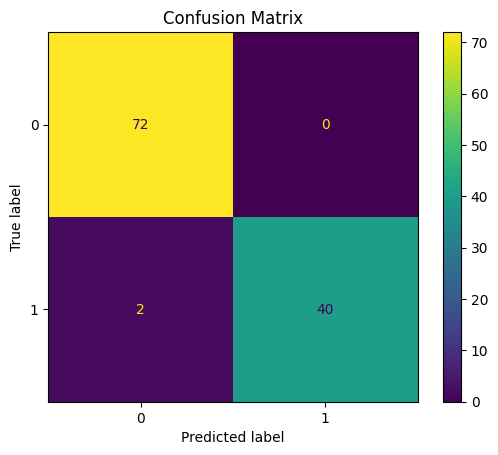

Explanation:
The model makes a small number of false positives and false negatives.
Most cases are classified correctly, but a few tumors are still misclassified.


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_grid) # calculating the confusion matrix for the predictions made by the best model found by grid search

disp = ConfusionMatrixDisplay(confusion_matrix=cm) # creating a confusion matrix display object using the calculated confusion matrix
disp.plot()
plt.title("Confusion Matrix")
plt.show()

print("Explanation:")
print("The model makes a small number of false positives and false negatives.")
print("Most cases are classified correctly, but a few tumors are still misclassified.")

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html


In [23]:

model = LogisticRegression(max_iter=10000) # creating a logistic regression model with a higher max_iter to ensure convergence
model.fit(X_train, y_train)

imp = pd.DataFrame({ # creating a DataFrame to show feature importance based on the coefficients of the logistic regression model
    "Feature": X_train.columns,
    "Coef": model.coef_[0]
}).sort_values(by="Coef", key=abs, ascending=False)

print(imp.head(10)) # showing the top 10 features based on the absolute value of their coefficients


# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html

            Feature      Coef
23  perimeter_worst -0.064576
3    perimeter_mean -0.061442
24       area_worst  0.030938
14          area_se  0.029892
22    texture_worst -0.025557
4         area_mean -0.019878
2      texture_mean -0.019228
21     radius_worst -0.010929
1       radius_mean -0.010253
12       texture_se -0.001379



Features with larger coefficients affect the prediction more.

# Part VII — Research-Oriented Extensions

Among the models, Logistic Regression performed the best in terms of overall balance between accuracy and F1-score. It gave stable and consistent results compared to the others.

It is also one of the simplest models. Compared to Decision Tree and KNN it is easier to understand and does not overfit easily.

In a real application, Logistic Regression would be a good choice because it is both reliable and interpretable. It is important to understand why the model makes decisions.

 More complex models can sometimes give slightly better results but they are harder to explain. Simpler models like Logistic Regression may be slightly less flexible but are easier to trust.

Two additional methods that were not used in this notebook are Random Forest and Support Vector Machine.
Random Forest is a tree-based method that builds many decision trees and combines their results. It usually gives better performance than a single decision tree because it reduces overfitting. For this dataset, it could work well since there are many features but it may be harder to interpret.

Support Vector Machine tries to find the best boundary that separates classes. It works well especially when the data is not linearly separable. It could achieve high accuracy but it may require scaling and can be slower compared to other models.

The dataset is relatively small, so it may not represent all real cases. There can also be sampling bias since the data may come from a limited source. Some important information might be missing it can affect the results.

Overfitting is possible for models like Decision Tree. Preprocessing steps such as encoding and scaling were applied with certain assumptions but it may not always be valid. Because of these factors the model may not generalize well to new data.

For improvement, a larger dataset can be used. More models can be tested to compare performance. Also, better feature selection methods can be applied to improve results.


- Dataset source: The dataset used in this project is the breast cancer dataset.
- Library versions: pandas, numpy, scikit-learn seaborn and matplotlib.
- Random seed: random_state=42 was used for reproducibility.
- Preprocessing steps: categorical encoding and feature scaling were applied.
- Models used: Logistic Regression, Decision Tree and Pipeline model.
- Evaluation strategy: train-test split and cross-validation were used.

In [24]:
import numpy as np
from sklearn.metrics import accuracy_score

manual_acc = np.sum(y_test == y_pred) / len(y_test) # manually calculating accuracy by comparing predictions to true labels and dividing by the number of samples

sklearn_acc = accuracy_score(y_test, y_pred) # calculating accuracy using the accuracy_score function from scikit-learn 

print(f"Manual Accuracy:      {manual_acc}")
print(f"Scikit-learn Accuracy:{sklearn_acc}")
print(f"Match:                {np.isclose(manual_acc, sklearn_acc)}")


# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
# https://numpy.org/doc/stable/reference/generated/numpy.sum.html


Manual Accuracy:      1.0
Scikit-learn Accuracy:1.0
Match:                True


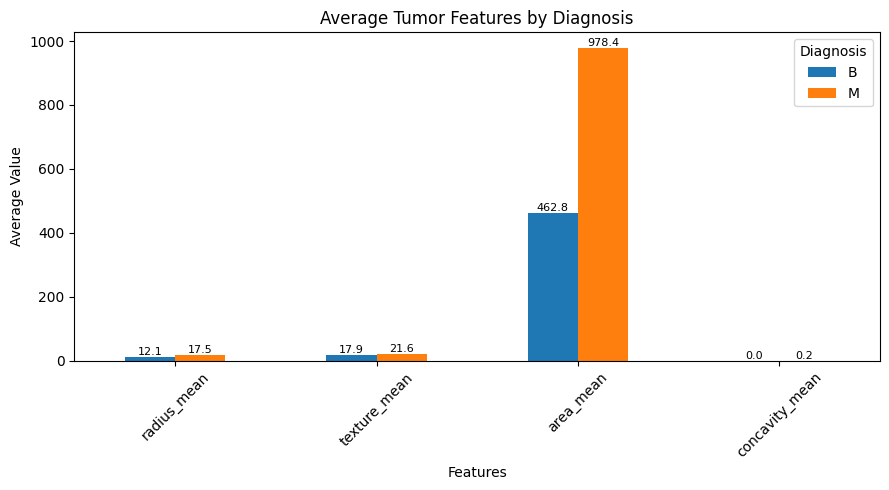

In [25]:
features = ["radius_mean", "texture_mean", "area_mean", "concavity_mean"] # selecting features to compare by diagnosis

group_means = df.groupby("diagnosis")[features].mean().T # calculating the mean of the selected features for each diagnosis group and transposing the result for plotting

ax = group_means.plot(kind="bar", figsize=(9,5)) # creating a bar plot to compare the average feature values by diagnosis
plt.title("Average Tumor Features by Diagnosis")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Diagnosis")

# annotate values
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8)

plt.tight_layout()
plt.show()



# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html


This chart shows that malignant tumors generally have higher feature values than benign ones. This explains their role in classification.

# Final Reflection

In this project, I used the Breast Cancer dataset to classify tumors as malignant or benign. During the analysis, I observed that features such as radius, area and concavity show clear differences between the two classes which makes them useful. I tested several models and Logistic Regression performed the best overall because it provided strong results while still being simple and interpretable.
One important preprocessing step was converting the target variable into numeric form and applying feature scaling when necessary. Some models are sensitive to feature magnitude. A limitation of this study is that the dataset may not cover all possible real-world variations which can affect how well the model generalizes.
If I had more time, I would experiment with more advanced models, try different feature selection techniques and test the model on a larger or more diverse dataset to improve performance and reliability.

 1. Goal -
The goal of this study is to classify breast tumors as malignant or benign using the Breast Cancer dataset.

 2. Method -
Logistic Regression was selected as the main model because it is simple and works well for binary classification. Feature scaling was applied to improve performance.

 3. Output -
The model achieved high accuracy and F1-score on the test data.

 4. Interpretation -
The model can successfully distinguish between malignant and benign tumors based on the given features.

 5. Limitation -
The dataset is not very large and may not represent all possible real-world cases, the model may not generalize perfectly.